In [1]:
# Testing

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings("ignore", category=FutureWarning, message=".*use_inf_as_na.*")

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

In [42]:
# import kagglehub
# import shutil
# import os

# # Download latest version
# path = kagglehub.dataset_download("datasetengineer/eviot-predictivemaint-dataset")

# print("Path to dataset files:", path)

# # Move the dataset to the data/ folder
# if os.path.exists('data'):
#     shutil.rmtree('data')  # Remove existing data folder if any
# shutil.copytree(path, 'data')

# print("Dataset moved to data/ folder.")


#####

#Use for a .mat file
import scipy.io as sio

# Load the .mat file
mat_data = sio.loadmat('/Users/noam/Downloads/Machine Learning Code/Machine-Learning-Final-Project/Oxford_Battery_Degradation_Dataset_1.mat') #put your own file directory

# A .mat file loads as a Python dictionary. 
# You can see the variables stored inside it by checking the keys:
print(mat_data.keys())

# Extract the data for the first battery
cell1_data = mat_data['Cell1']

# Print the names of the variables stored inside Cell 1
print("Variables inside Cell 1:", cell1_data.dtype.names)

# Look inside the data packet for Cycle 0
cycle_0 = cell1_data['cyc0000'][0, 0] # [0,0] is often needed to unpack MATLAB structs in Python

# Print the names of the variables stored inside this cycle
print("Variables inside cyc0000:", cycle_0.dtype.names)

dict_keys(['__header__', '__version__', '__globals__', 'Cell1', 'Cell2', 'Cell3', 'Cell4', 'Cell5', 'Cell6', 'Cell7', 'Cell8'])
Variables inside Cell 1: ('cyc0000', 'cyc0100', 'cyc0200', 'cyc0300', 'cyc0400', 'cyc0500', 'cyc0600', 'cyc0700', 'cyc0800', 'cyc0900', 'cyc1000', 'cyc1100', 'cyc1200', 'cyc1300', 'cyc1400', 'cyc1600', 'cyc1800', 'cyc1900', 'cyc2000', 'cyc2100', 'cyc2200', 'cyc2300', 'cyc2400', 'cyc2500', 'cyc2600', 'cyc2700', 'cyc2800', 'cyc2900', 'cyc3000', 'cyc3100', 'cyc3200', 'cyc3300', 'cyc3500', 'cyc3600', 'cyc3700', 'cyc3800', 'cyc3900', 'cyc4000', 'cyc4100', 'cyc4200', 'cyc4300', 'cyc4400', 'cyc4500', 'cyc4600', 'cyc4800', 'cyc5000', 'cyc5100', 'cyc5200', 'cyc5300', 'cyc5400', 'cyc5500', 'cyc5600', 'cyc5700', 'cyc5800', 'cyc5900', 'cyc6000', 'cyc6100', 'cyc6200', 'cyc6300', 'cyc6400', 'cyc6500', 'cyc6600', 'cyc6700', 'cyc6800', 'cyc6900', 'cyc7000', 'cyc7100', 'cyc7200', 'cyc7300', 'cyc7400', 'cyc7500', 'cyc7600', 'cyc7700', 'cyc7800', 'cyc7900', 'cyc8000', 'cyc8100',

In [ ]:
# Commment in to check if this works. AI wrote it real quick

# import scipy.io as sio
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score, mean_squared_error

# # 1. Load the Data
# file_name = 'Oxford_Battery_Degradation_Dataset_1.mat'
# mat_data = sio.loadmat(file_name)
# cell1_data = mat_data['Cell1']
# cycle_names = cell1_data.dtype.names

# # 2. Extract Cycle Numbers and Discharge Capacity
# cycles = []
# capacities = []

# for cyc_name in cycle_names:
#     # Get the integer cycle number from the string (e.g., 'cyc0100' -> 100)
#     cycle_num = int(cyc_name.replace('cyc', ''))
    
#     # Open the specific cycle's data packet
#     # The [0, 0] is required to unpack scipy's nested MATLAB structures
#     cycle_packet = cell1_data[cyc_name][0, 0]
    
#     # Extract the Discharge Capacity (C1dc)
#     # .flatten()[0] ensures we grab the single number out of the array
#     discharge_capacity = cycle_packet['C1dc'].flatten()[0]
    
#     cycles.append(cycle_num)
#     capacities.append(discharge_capacity)

# # 3. Create the clean Pandas DataFrame
# df = pd.DataFrame({
#     'Cycle_Index': cycles,
#     'Capacity': capacities
# })

# # Calculate SOH (Current Capacity / Initial Capacity)
# initial_capacity = df['Capacity'].iloc[0]
# df['SOH'] = df['Capacity'] / initial_capacity

# # 4. Prepare for Regression
# X = df[['Cycle_Index']] 
# y = df['SOH']

# # Split into 80% Training and 20% Testing
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 5. Train the Linear Regression Model
# model = LinearRegression()
# model.fit(X_train, y_train)

# # 6. Evaluate and Print Results
# y_pred = model.predict(X_test)
# r2 = r2_score(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)

# print(f"--- Model Results for Cell 1 ---")
# print(f"R-squared (R2) Score: {r2:.4f}")
# print(f"Mean Squared Error (MSE): {mse:.6f}")
# print(f"Degradation Rate: {model.coef_[0]:.8f} SOH drop per cycle")

# # 7. Visualize the Degradation Curve
# plt.figure(figsize=(10, 6))
# plt.scatter(X, y, color='blue', label='Actual Battery SOH', alpha=0.6)
# plt.plot(X_test, y_pred, color='red', linewidth=3, label='Linear Regression Fit')
# plt.title('Oxford Dataset: Battery SOH Degradation over Cycles (Cell 1)')
# plt.xlabel('Cycle Number')
# plt.ylabel('State of Health (SOH)')
# plt.legend()
# plt.grid(True)
# plt.show()

In [17]:
# df = pd.read_csv("data/synthetic_ev_battery_5year_50cols_multimfg_3M.csv")
df = pd.read_csv('data/EV_Predictive_Maintenance_Dataset_15min.csv')

print(f"Shape: {df.shape}")
print("Columns:", df.columns.tolist())
print(df.head(5))
print(df.dtypes)

Shape: (175393, 30)
Columns: ['Timestamp', 'SoC', 'SoH', 'Battery_Voltage', 'Battery_Current', 'Battery_Temperature', 'Charge_Cycles', 'Motor_Temperature', 'Motor_Vibration', 'Motor_Torque', 'Motor_RPM', 'Power_Consumption', 'Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency', 'Tire_Pressure', 'Tire_Temperature', 'Suspension_Load', 'Ambient_Temperature', 'Ambient_Humidity', 'Load_Weight', 'Driving_Speed', 'Distance_Traveled', 'Idle_Time', 'Route_Roughness', 'RUL', 'Failure_Probability', 'Maintenance_Type', 'TTF', 'Component_Health_Score']
             Timestamp       SoC       SoH  Battery_Voltage  Battery_Current  \
0  2020-01-01 00:00:00  0.826099  0.941338       210.163881       -22.753095   
1  2020-01-01 00:15:00  0.064728  0.916059       364.000102       -27.701120   
2  2020-01-01 00:30:00  0.873643  0.908020       388.855089       -36.646406   
3  2020-01-01 00:45:00  0.853009  0.916476       370.570602       -37.609429   
4  2020-01-01 01:00:00  0.947540  0.913206      

In [18]:
# Drop leakage + useless columns for EV Predictive Maintenance dataset
drop_cols = [
    "Timestamp",  # string timestamp
    # Add other columns if needed, e.g., direct leakage
]

# Encode categorical columns
df_model = pd.get_dummies(df.drop(columns=drop_cols), 
                          columns=["Maintenance_Type"],  # assuming this is categorical
                          drop_first=True)

# Define features and target
target = "SoH"  # State of Health
X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Features: {X.shape[1]}")
print(f"Sample size: {X.shape[0]}")
print(X.columns.tolist())

Features: 30
Sample size: 175393
['SoC', 'Battery_Voltage', 'Battery_Current', 'Battery_Temperature', 'Charge_Cycles', 'Motor_Temperature', 'Motor_Vibration', 'Motor_Torque', 'Motor_RPM', 'Power_Consumption', 'Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency', 'Tire_Pressure', 'Tire_Temperature', 'Suspension_Load', 'Ambient_Temperature', 'Ambient_Humidity', 'Load_Weight', 'Driving_Speed', 'Distance_Traveled', 'Idle_Time', 'Route_Roughness', 'RUL', 'Failure_Probability', 'TTF', 'Component_Health_Score', 'Maintenance_Type_1', 'Maintenance_Type_2', 'Maintenance_Type_3']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)   # use fit from train only

print(f"Train size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")

Train size: 140,314
Test size:  35,079


In [20]:
# Check for potential leakage in the EV predictive maintenance dataset
print("Top correlations with SoH (target):")
corr_with_soh = df.corr(numeric_only=True)["SoH"].sort_values(ascending=False)
print(corr_with_soh.head(10))

# Check for highly correlated features that might indicate leakage
print("\nFeatures with correlation > 0.9 with SoH:")
high_corr = corr_with_soh[corr_with_soh > 0.9]
print(high_corr)

# Check for redundant columns (e.g., identical or highly correlated)
print("\nCheck for redundant columns:")
# Example: if 'RUL' and 'TTF' are the same
if 'RUL' in df.columns and 'TTF' in df.columns:
    print(f"RUL and TTF correlation: {df['RUL'].corr(df['TTF'])}")

Top correlations with SoH (target):
SoH                     1.000000
Charge_Cycles           0.004460
Tire_Pressure           0.004245
Load_Weight             0.003589
Ambient_Humidity        0.003324
Motor_Temperature       0.002424
Brake_Pad_Wear          0.002280
Motor_Torque            0.001495
Reg_Brake_Efficiency    0.001095
RUL                     0.000747
Name: SoH, dtype: float64

Features with correlation > 0.9 with SoH:
SoH    1.0
Name: SoH, dtype: float64

Check for redundant columns:
RUL and TTF correlation: 0.0013967190571160062


In [21]:
# Adaptive: Drop features with high correlation to target from scaled training data
corr_with_target_train = pd.DataFrame(X_train_scaled, columns=X_train.columns).corrwith(pd.Series(y_train.values))
high_corr_threshold = 0.95
high_corr_features = corr_with_target_train[abs(corr_with_target_train) > high_corr_threshold].index.tolist()

if high_corr_features:
    print(f"Dropping features with |correlation| > {high_corr_threshold} to target: {high_corr_features}")
    X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns).drop(columns=high_corr_features)
    X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns).drop(columns=high_corr_features)
else:
    print(f"No features with |correlation| > {high_corr_threshold} to target found.")
    X_train_final = pd.DataFrame(X_train_scaled, columns=X_train.columns)
    X_test_final = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f"Final feature count: {X_train_final.shape[1]}")
print(X_train_final.columns.tolist())

No features with |correlation| > 0.95 to target found.
Final feature count: 30
['SoC', 'Battery_Voltage', 'Battery_Current', 'Battery_Temperature', 'Charge_Cycles', 'Motor_Temperature', 'Motor_Vibration', 'Motor_Torque', 'Motor_RPM', 'Power_Consumption', 'Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency', 'Tire_Pressure', 'Tire_Temperature', 'Suspension_Load', 'Ambient_Temperature', 'Ambient_Humidity', 'Load_Weight', 'Driving_Speed', 'Distance_Traveled', 'Idle_Time', 'Route_Roughness', 'RUL', 'Failure_Probability', 'TTF', 'Component_Health_Score', 'Maintenance_Type_1', 'Maintenance_Type_2', 'Maintenance_Type_3']


In [25]:
# Train
model = LinearRegression()
model.fit(X_train_final, y_train)
print("Model trained")

# Evaluate
y_pred = model.predict(X_test_final)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR²   : {r2:.4f}    (1.0 = perfect)")
print(f"MAE  : {mae:.4f}  (avg error in % SOH)")
print(f"RMSE : {rmse:.4f}  (penalises large errors)")

Model trained

R²   : -0.0002    (1.0 = perfect)
MAE  : 0.1154  (avg error in % SOH)
RMSE : 0.1649  (penalises large errors)


In [ ]:
# Trying to figure out why r^2 is 0

# print("=== X_train_final ===")
# print(X_train_final.describe())

# print("\n=== X_test_final ===")
# print(X_test_final.describe())

# print(X_train_final.shape, X_test_final.shape)
# X_train_final.head()

# print(df.columns.tolist())
# print(df.shape)
# print(df.dtypes)

# import matplotlib.pyplot as plt

# correlations = df.drop(columns=['Timestamp']).corr()['RUL'].drop('RUL').sort_values()
# correlations.plot(kind='barh', figsize=(8, 10), title='Feature correlation with RUL')
# plt.tight_layout()
# plt.show()

# import numpy as np
# print(np.corrcoef(X_train_final['Charge_Cycles'], y_train)[0,1])

# from sklearn.ensemble import RandomForestRegressor

# model_rf = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
# model_rf.fit(X_train_final, y_train)

# y_pred_rf = model_rf.predict(X_test_final)

# r2_rf = r2_score(y_test, y_pred_rf)
# mae_rf = mean_absolute_error(y_test, y_pred_rf)
# print(f"R²  : {r2_rf:.4f}")
# print(f"MAE : {mae_rf:.4f}")

R²  : -0.1398
MAE : 0.1272


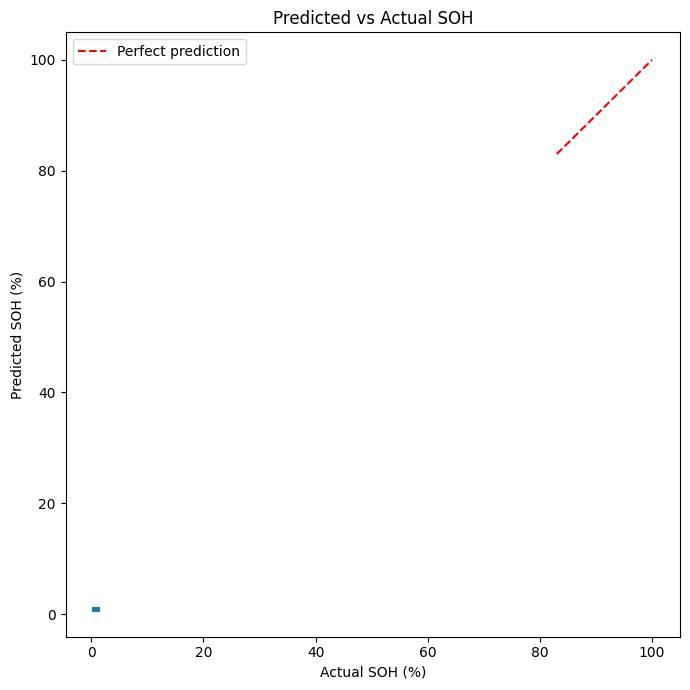

In [24]:
# Predicted vs actual plot
sample = np.random.choice(len(y_test), 5000, replace=False)
y_test_arr = np.array(y_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test_arr[sample], y_pred[sample], alpha=0.2, s=5)
plt.plot([83, 100], [83, 100], "r--", label="Perfect prediction")
plt.xlabel("Actual SOH (%)")
plt.ylabel("Predicted SOH (%)")
plt.title("Predicted vs Actual SOH")
plt.legend()
plt.tight_layout()
plt.show()